In [1]:
import numpy as np

# 原始列表
_total_classes = 10
_known_classes = 5
classes = [i for i in range(_total_classes)][-(_total_classes - _known_classes):]
feature_proto_list = [np.eye(768, dtype=int)[num].tolist() for num in classes]

# 生成 768 维的独热编码列表
nums = [1, 2, 3, 4, 5]
one_hot_vectors = [np.eye(768, dtype=int)[num].tolist() for num in nums]

# 检查结果
assert len(one_hot_vectors) == 5, "列表应包含五个元素"
assert len(one_hot_vectors[0]) == 768, "每个向量应为 768 维"
assert sum(one_hot_vectors[0]) == 1, "每个向量有且仅有一个位置为 1"

# print(one_hot_vectors[0])

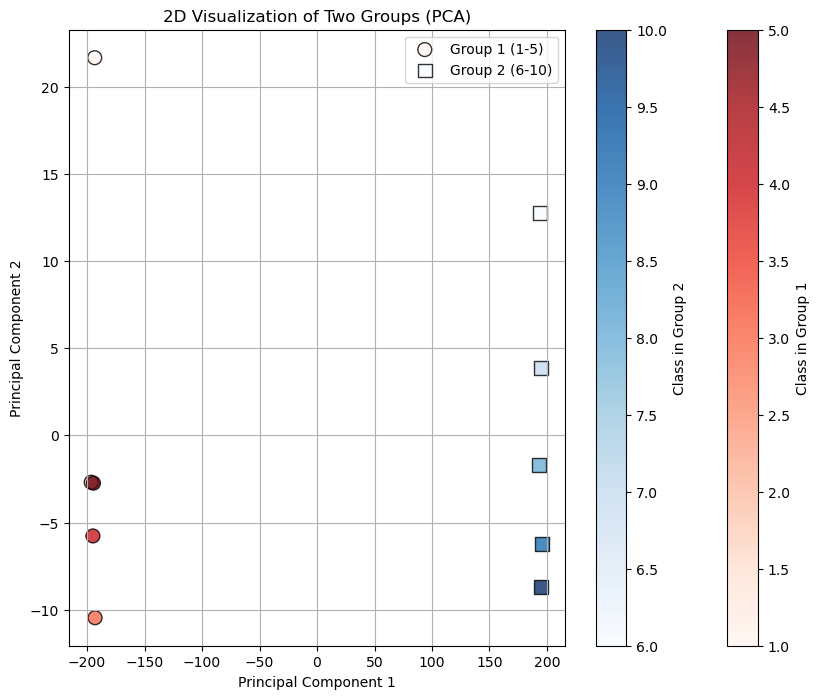

In [5]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 生成两组数据
a = torch.randn(768)  # 基向量 a
b = torch.randn(768)  # 基向量 b

# 第一组数据（classes 1-5，基于基向量 a）
classes1 = [1, 2, 3, 4, 5]
feature_proto_list1 = [torch.randn(768) + 10 * a for _ in classes1]

# 第二组数据（classes 6-10，基于基向量 b）
classes2 = [6, 7, 8, 9, 10]
feature_proto_list2 = [torch.randn(768) + 10 * b for _ in classes2]

# 合并两组数据
all_features = torch.stack(feature_proto_list1 + feature_proto_list2).numpy()
all_classes = classes1 + classes2  # 合并后的类别标签 [1,2,3,4,5,6,7,8,9,10]

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(all_features)

# 绘制二维散点图，区分两组数据
plt.figure(figsize=(10, 8))

# 第一组（classes 1-5，红色系）
scatter1 = plt.scatter(
    reduced_features[:5, 0],  # 前5个点
    reduced_features[:5, 1],
    c=classes1,               # 颜色映射为类别1-5
    cmap='Reds',             # 红色渐变
    s=100,
    alpha=0.8,
    edgecolors='k',          # 黑色边框
    label='Group 1 (1-5)'
)

# 第二组（classes 6-10，蓝色系）
scatter2 = plt.scatter(
    reduced_features[5:, 0],  # 后5个点
    reduced_features[5:, 1],
    c=classes2,               # 颜色映射为类别6-10
    cmap='Blues',            # 蓝色渐变
    s=100,
    alpha=0.8,
    marker='s',              # 方形标记
    edgecolors='k',
    label='Group 2 (6-10)'
)

# 添加标签和标题
plt.title('2D Visualization of Two Groups (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter1, label='Class in Group 1')
plt.colorbar(scatter2, label='Class in Group 2')
plt.legend()  # 显示图例
plt.grid(True)

plt.show()

In [6]:
import torch

a = torch.tensor([[-0., -1], [-1., -0]])

x = torch.tensor([[0.1, 0.9]])
ans = torch.cdist(a, x, p=2)
ans

tensor([[1.9026],
        [1.4213]])